[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework2.ipynb)

In [1]:
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import pandas as pd


First, we create the mouse dataset -- one bigger spherical dataset and two smaller

In [2]:
head_mean = np.array([0,0])
ear1_mean = np.array([-0.8,0.8])
ear2_mean = np.array([0.8,0.8])

head_cov = np.array([[0.16, 0], [0, 0.16]])
ear_cov = np.array([[0.04, 0],[0, 0.04]])

head_data = np.random.multivariate_normal(head_mean, head_cov, 300)
ear_1_data = np.random.multivariate_normal(ear1_mean, ear_cov, 100)
ear_2_data = np.random.multivariate_normal(ear2_mean, ear_cov, 100)

data = np.vstack([head_data, ear_1_data, ear_2_data])
N, d = data.shape


# Question one
We want to create decision boundary between clusters.

**Main Idea**

We train a GMM model, which base on the EM algorithm to recognise clusters. Then we create a dense grid, which covers our plane and use our model to predict a cluster for each point from a grid. Then cluster boundary will contain points, where number of cluster changes.

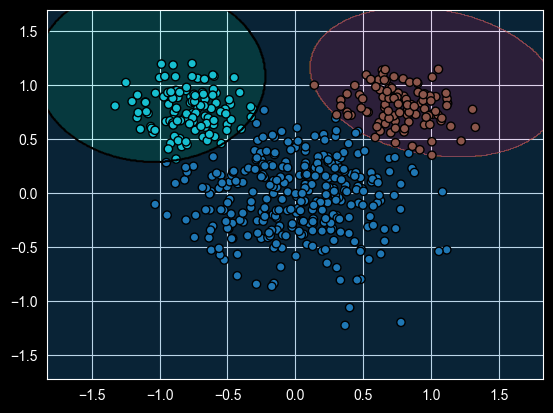

In [6]:
from sklearn.mixture import GaussianMixture as gmm

model = gmm(n_components=3, random_state=0)
model.fit(data)

margin = 0.5
x_min, x_max = data[:,0].min()-margin, data[:,0].max()+margin
y_min, y_max = data[:,1].min()-margin, data[:,1].max()+margin
x_axis, y_axis = np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500)

X, Y = np.meshgrid(x_axis, y_axis)
grid = np.c_[X.ravel(), Y.ravel()]

result = model.predict(grid)
result = result.reshape(X.shape)

plt.contourf(X, Y, result, alpha=0.3, cmap='tab10')
plt.contour(X, Y, result, levels=[1,3], colors='black')

plt.scatter(data[:,0], data[:,1], c=model.predict(data), cmap='tab10', edgecolor='k')

plt.show()

# Conlusion
We expected that the plane would be divided into 3 regions, but we observe that two clusters form separate elipses and the rest belongs to the third cluster. This is due to the fact that EM algorithm assigns the cluster with highest probability of occuring to each point. Two cluster have smaller variance, so their elipses are relatively small, while data in the third cluster is more sparsed, so its elipse covers the most of the remaining area of the plane.

# Question two
We want to test how many clusters would minimize variance between classes. Since our data comes from Euclidean space, we will use K-means algorithm.

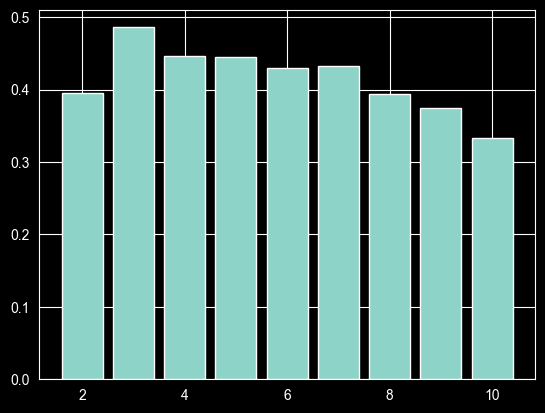

Clusters with the best inertia score is K = 3


In [4]:
silhouette = 11 * [0]
for K in range(2, 11):
    kmeans = sk.cluster.KMeans(n_clusters=K, random_state=42, n_init = 50)
    silhouette[K] = sk.metrics.silhouette_score(data, kmeans.fit_predict(data))
index = np.arange(2, 11  , 1)
silhouette = silhouette[2:11]
plt.bar(index, silhouette)
plt.show()
print("Clusters with the best inertia score is K = " + str(silhouette.index(max(silhouette)) + 2))

We know that our data comes from Gaussian distribution, so we can choose the best K using well-known from SAD course BIC (Bayesian Information Criterion) metric

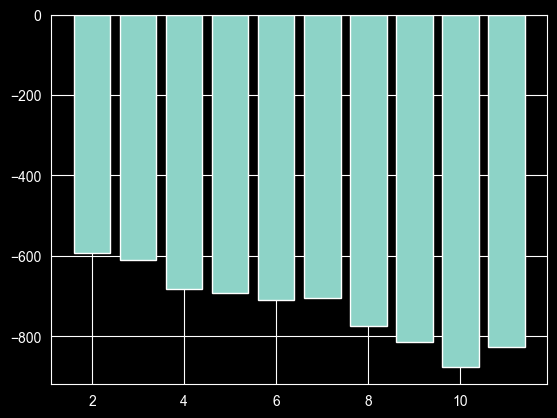

In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV

def gmm_bic_score(estimator, X):
    return -estimator.bic(X)

parameters_grid = {
    "n_components": range(2, 15),
    "covariance_type": ["spherical"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=parameters_grid, scoring=gmm_bic_score
)
grid_search.fit(data)

df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df["mean_test_score"]
df = df.rename(
    columns={
        "param_n_components": "Number_of_components",
        "param_covariance_type": "Type_of_covariance",
        "mean_test_score": "BIC_score",
    }
)
plt.bar(df.Number_of_components[:10], df.BIC_score[:10])
plt.show()

# Conclusion
We observe that Silhouette metric gives noticably the best result for K = 3, while BIC, which uses the fact that our data is Gausssian Mixture and prefers smaller number of clusters gives comparable answers for K in range [2, 6].